# 01 — Data audit & EDA

In [1]:
from pathlib import Path
import sys, json, warnings
warnings.filterwarnings("ignore")

HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks" else HERE
while not (ROOT / "config" / "project_config.json").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

FIG_DIR = ROOT / "reports" / "figures"
TABLE_DIR = ROOT / "reports" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)

Project root: C:\Users\wiame.bourass\Downloads\sephora-consumer-voice-intelligence-llm-first\sephora-consumer-voice-intelligence-llm-first


## 1. Chargement des données

In [2]:
from src.io_utils import read_products, read_all_reviews, EXPECTED_REVIEW_FILES

products = read_products(ROOT)
review_cols = [
    "author_id", "rating", "is_recommended", "helpfulness",
    "total_feedback_count", "submission_time", "review_text", "review_title",
    "skin_tone", "skin_type", "product_id", "product_name", "brand_name", "price_usd"
]
reviews = read_all_reviews(ROOT, usecols=review_cols)
reviews["submission_time"] = pd.to_datetime(reviews["submission_time"], errors="coerce")

print("Products shape:", products.shape)
print("Reviews shape:", reviews.shape)
display(products.head(3))
display(reviews.head(3))

Products shape: (8494, 27)
Reviews shape: (1094411, 16)


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


,author_id,rating,is_recommended,helpfulness,total_feedback_count,submission_time,review_text,review_title,skin_tone,skin_type,product_id,product_name,brand_name,price_usd,source_file,source_row
0,1741593524,5,1.0,1.0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,dry,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0,reviews_0-250.csv,0
1,31423088263,1,0.0,NaN,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,reviews_0-250.csv,1
2,5061282401,5,1.0,NaN,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,dry,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,reviews_0-250.csv,2


## 2. Volume par fichier

,source_file,n_reviews
0,reviews_0-250.csv,602130
1,reviews_250-500.csv,206725
2,reviews_750-1250.csv,119317
3,reviews_500-750.csv,116262
4,reviews_1250-end.csv,49977


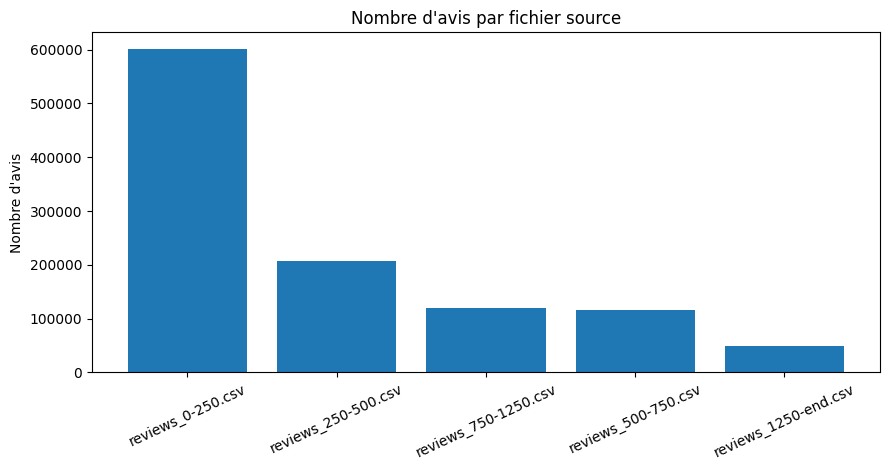

In [3]:
rows_by_file = reviews.groupby("source_file").size().sort_values(ascending=False).rename("n_reviews").reset_index()
display(rows_by_file)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(rows_by_file["source_file"], rows_by_file["n_reviews"])
ax.set_title("Nombre d'avis par fichier source")
ax.set_ylabel("Nombre d'avis")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_reviews_by_file.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. Couverture du catalogue

In [4]:
catalog_n = products["product_id"].nunique()
reviewed_n = reviews["product_id"].nunique()
matched = reviews["product_id"].isin(products["product_id"]).mean()
print(f"Produits catalogue : {catalog_n:,}")
print(f"Produits avec au moins un avis : {reviewed_n:,}")
print(f"Taux de product_id review matché au catalogue : {matched:.4%}")

unmatched_ids = reviews.loc[~reviews["product_id"].isin(products["product_id"]), "product_id"].drop_duplicates()
print("Product IDs non matchés :", len(unmatched_ids))

Produits catalogue : 8,494
Produits avec au moins un avis : 2,351
Taux de product_id review matché au catalogue : 100.0000%
Product IDs non matchés : 0


## 4. Catégorie primaire

,n_products
primary_category,
Skincare,2351


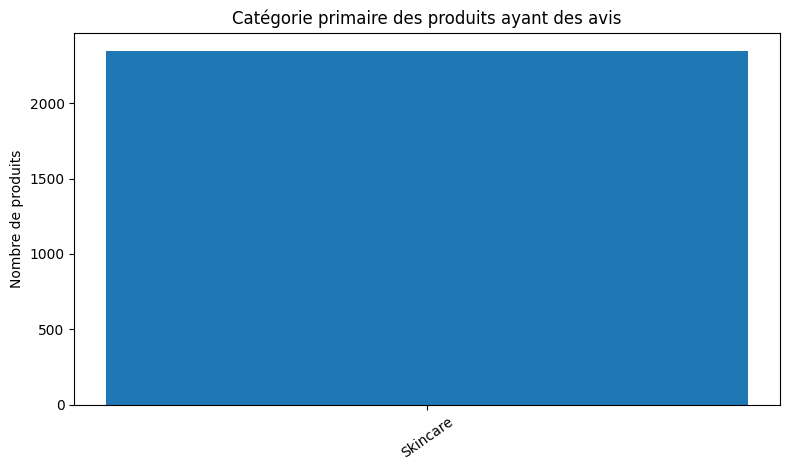

8494


In [5]:
reviewed_products = products[products["product_id"].isin(reviews["product_id"].unique())].copy()
cat_counts = reviewed_products["primary_category"].fillna("MISSING").value_counts()
display(cat_counts.to_frame("n_products"))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(cat_counts.index.astype(str), cat_counts.values)
ax.set_title("Catégorie primaire des produits ayant des avis")
ax.set_ylabel("Nombre de produits")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_reviewed_products_primary_category.png", dpi=160, bbox_inches="tight")
plt.show()
print(len(products["product_id"]))

,n_products
Produits avec avis,2351
Produits sans avis,6143


Total produits catalogue : 8494
Produits avec avis       : 2351
Produits sans avis       : 6143
Couverture des reviews   : 27.68 %


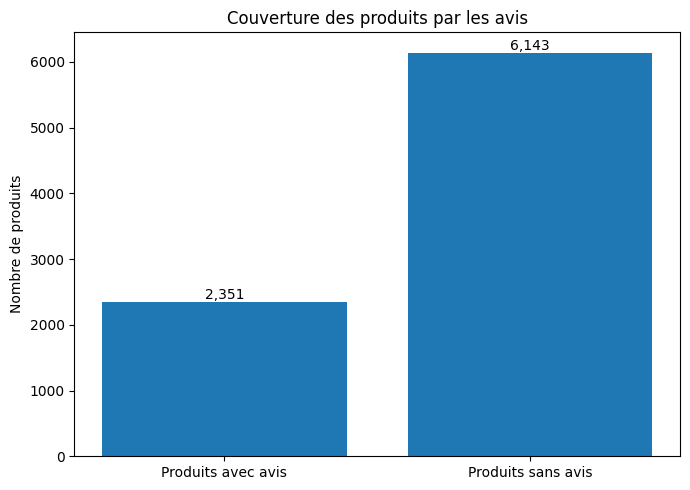

In [6]:
# Nombre total de produits uniques dans le catalogue
n_total_products = products["product_id"].nunique()

# IDs de produits présents dans les reviews
reviewed_ids = reviews["product_id"].dropna().unique()

# Produits du catalogue ayant au moins un avis
reviewed_products = products[
    products["product_id"].isin(reviewed_ids)
].copy()

n_reviewed_products = reviewed_products["product_id"].nunique()

# Produits du catalogue sans avis
products_without_reviews = products[
    ~products["product_id"].isin(reviewed_ids)
].copy()

n_without_reviews = products_without_reviews["product_id"].nunique()


# Affichage des résultats
product_review_coverage = pd.Series({
    "Produits avec avis": n_reviewed_products,
    "Produits sans avis": n_without_reviews
})

display(product_review_coverage.to_frame("n_products"))

print("Total produits catalogue :", n_total_products)
print("Produits avec avis       :", n_reviewed_products)
print("Produits sans avis       :", n_without_reviews)

print(
    "Couverture des reviews   :",
    round(n_reviewed_products / n_total_products * 100, 2),
    "%"
)


# Visualisation
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    product_review_coverage.index,
    product_review_coverage.values
)

ax.set_title("Couverture des produits par les avis")
ax.set_ylabel("Nombre de produits")

# Afficher les valeurs au-dessus des barres
for i, value in enumerate(product_review_coverage.values):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

fig.tight_layout()

fig.savefig(
    FIG_DIR / "02_product_review_coverage.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

## 5. Valeurs manquantes — reviews

,missing_pct
helpfulness,51.31
review_title,28.39
skin_tone,15.58
is_recommended,15.35
skin_type,10.19
review_text,0.13
author_id,0.00
rating,0.00
total_feedback_count,0.00
submission_time,0.00


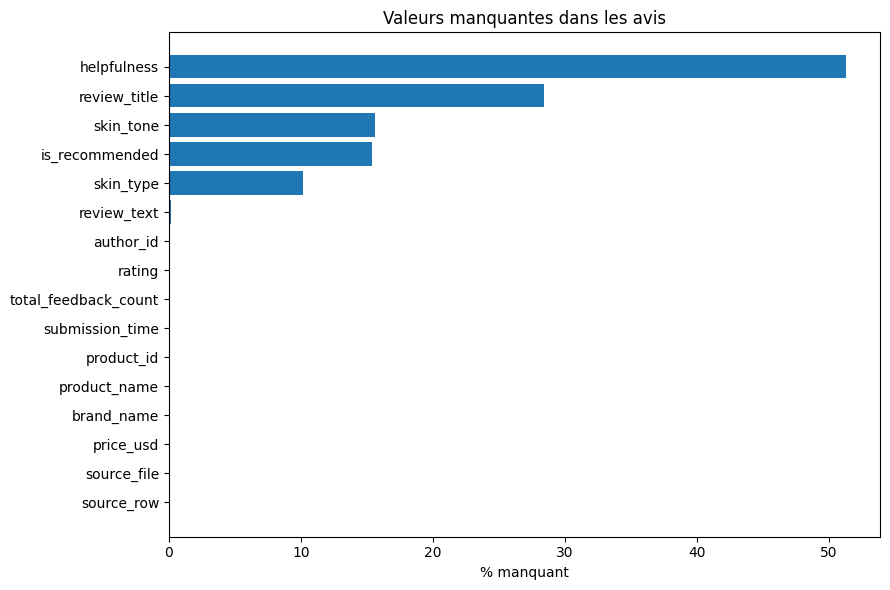

helpfulness             561592
review_title            310654
skin_tone               170539
is_recommended          167988
skin_type               111557
review_text               1444
author_id                    0
rating                       0
total_feedback_count         0
submission_time              0
product_id                   0
product_name                 0
brand_name                   0
price_usd                    0
source_file                  0
source_row                   0
dtype: int64


In [7]:
missing_reviews = (reviews.isna().mean() * 100).sort_values(ascending=False)
display(missing_reviews.to_frame("missing_pct").round(2))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(missing_reviews.index[::-1], missing_reviews.values[::-1])
ax.set_title("Valeurs manquantes dans les avis")
ax.set_xlabel("% manquant")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_missing_reviews.png", dpi=160, bbox_inches="tight")
plt.show()
print((reviews.isna().sum()).sort_values(ascending=False))

## 6. Valeurs manquantes — produits

,missing_pct
sale_price_usd,96.82
value_price_usd,94.69
variation_desc,85.28
child_max_price,67.58
child_min_price,67.58
highlights,25.98
size,19.20
variation_value,18.81
variation_type,17.00
tertiary_category,11.66


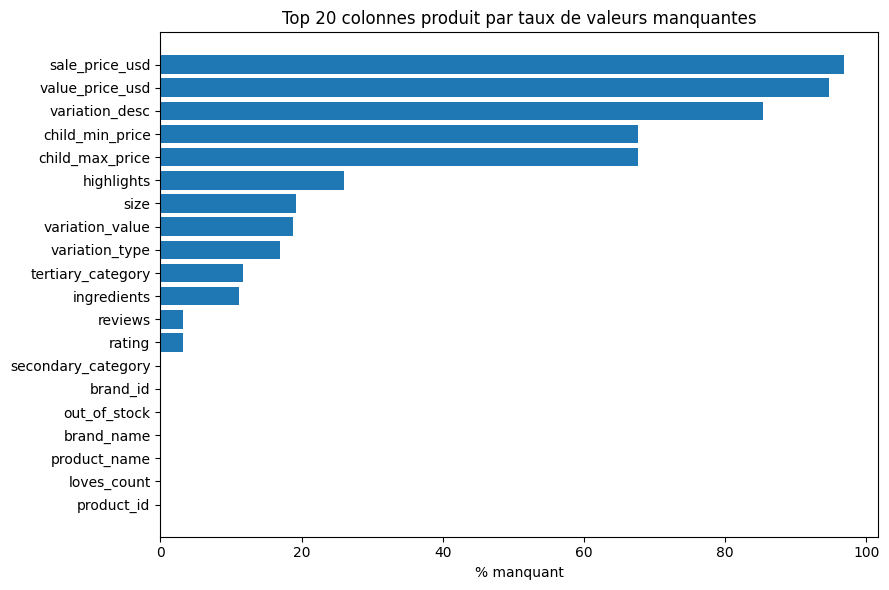

In [8]:
missing_products = (products.isna().mean() * 100).sort_values(ascending=False)
display(missing_products.to_frame("missing_pct").round(2).head(20))

fig, ax = plt.subplots(figsize=(9, 6))
top = missing_products.head(20).sort_values()
ax.barh(top.index, top.values)
ax.set_title("Top 20 colonnes produit par taux de valeurs manquantes")
ax.set_xlabel("% manquant")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_missing_products_top20.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Distribution des ratings

,count
rating,
1,61223
2,53032
3,81816
4,199389
5,698951


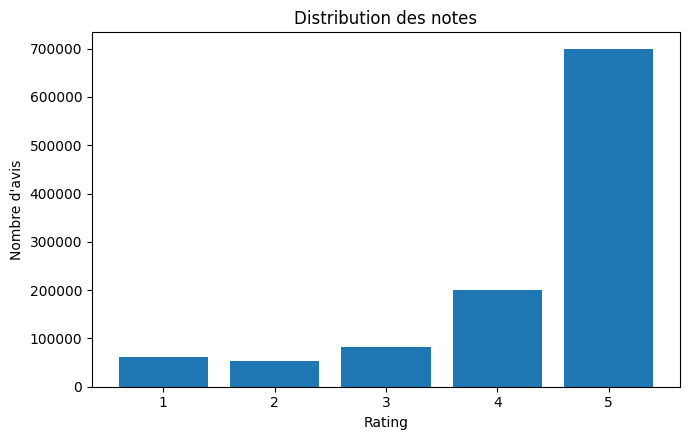

In [9]:
rating_counts = reviews["rating"].value_counts(dropna=False).sort_index()
display(rating_counts.to_frame("count"))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(rating_counts.index.astype(str), rating_counts.values)
ax.set_title("Distribution des notes")
ax.set_xlabel("Rating")
ax.set_ylabel("Nombre d'avis")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_rating_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. `is_recommended`

,count
is_recommended,
1.0,778160
MISSING,167988
0.0,148263


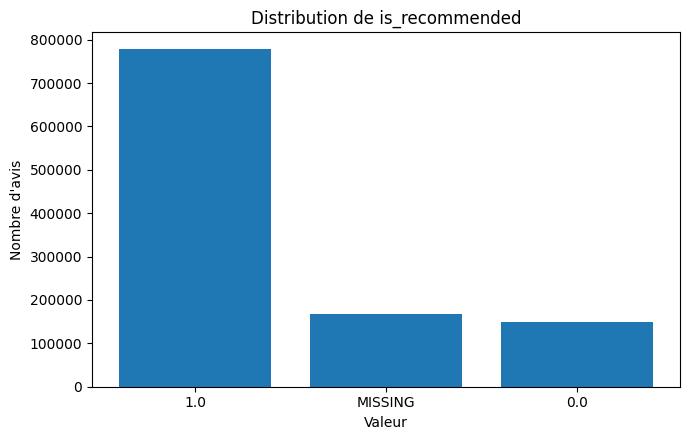

In [10]:
rec_counts = reviews["is_recommended"].fillna("MISSING").astype(str).value_counts()
display(rec_counts.to_frame("count"))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(rec_counts.index, rec_counts.values)
ax.set_title("Distribution de is_recommended")
ax.set_xlabel("Valeur")
ax.set_ylabel("Nombre d'avis")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_is_recommended_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Types de peau

,count
skin_type,
combination,544513
dry,185937
normal,131910
oily,120494
MISSING,111557


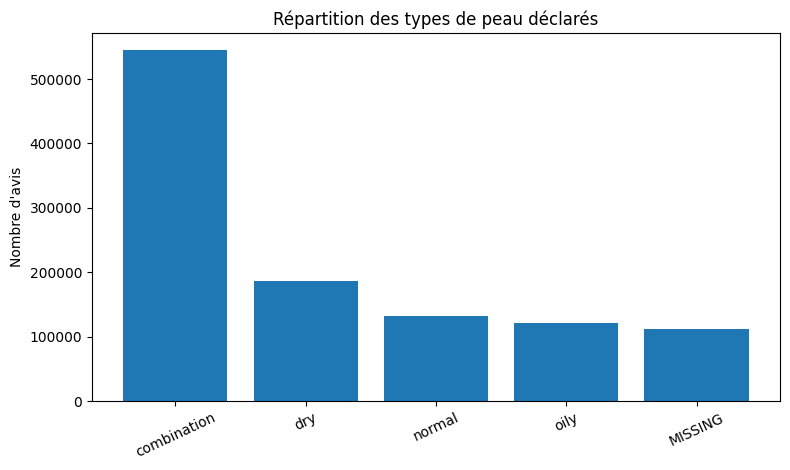

In [11]:
skin_counts = reviews["skin_type"].fillna("MISSING").value_counts()
display(skin_counts.to_frame("count"))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(skin_counts.index.astype(str), skin_counts.values)
ax.set_title("Répartition des types de peau déclarés")
ax.set_ylabel("Nombre d'avis")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_skin_type_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Longueur des avis

,word_count
0.00,0.0
0.25,33.0
0.50,51.0
0.75,78.0
0.90,115.0
0.95,146.0
0.99,229.0
1.00,1292.0


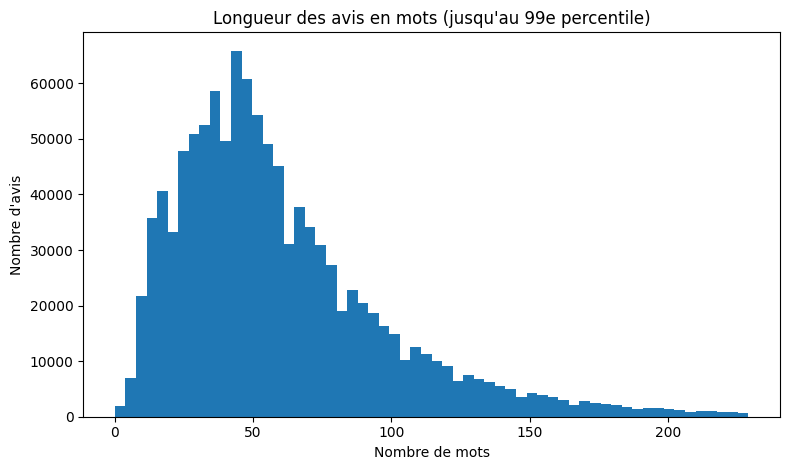

In [12]:
reviews["review_word_count"] = reviews["review_text"].fillna("").astype(str).str.findall(r"\b\w+\b").str.len()
q = reviews["review_word_count"].quantile([0, .25, .5, .75, .9, .95, .99, 1])
display(q.to_frame("word_count"))

upper = max(10, reviews["review_word_count"].quantile(.99))
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(reviews.loc[reviews["review_word_count"] <= upper, "review_word_count"], bins=60)
ax.set_title("Longueur des avis en mots (jusqu'au 99e percentile)")
ax.set_xlabel("Nombre de mots")
ax.set_ylabel("Nombre d'avis")
fig.tight_layout()
fig.savefig(FIG_DIR / "08_review_length_words.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Avis vides ou très courts

In [13]:
empty_mask = reviews["review_text"].isna() | reviews["review_text"].fillna("").astype(str).str.strip().eq("")
short_mask = reviews["review_word_count"] < 5
print(f"Avis vides/blancs : {empty_mask.sum():,} ({empty_mask.mean():.2%})")
print(f"Avis < 5 mots : {short_mask.sum():,} ({short_mask.mean():.2%})")
display(reviews.loc[short_mask & ~empty_mask, ["review_text", "rating", "product_name"]].head(20))

Avis vides/blancs : 1,444 (0.13%)
Avis < 5 mots : 3,083 (0.28%)


,review_text,rating,product_name
10330,This stuff is incredible!!,5,Lip Sleeping Mask Intense Hydration with Vitam...
10610,unbelievable results,5,Lip Sleeping Mask Intense Hydration with Vitam...
10707,Keep the lips hydrated,5,Lip Sleeping Mask Intense Hydration with Vitam...
10833,Must have overnight relief,5,Lip Sleeping Mask Intense Hydration with Vitam...
11572,New fav lip product.,5,Lip Sleeping Mask Intense Hydration with Vitam...
11895,Love love love this!,5,Lip Sleeping Mask Intense Hydration with Vitam...
11976,Keeps my lips moisturized!,5,Lip Sleeping Mask Intense Hydration with Vitam...
12113,The best product ever,5,Lip Sleeping Mask Intense Hydration with Vitam...
12300,Hydrates. Smells great.,5,Lip Sleeping Mask Intense Hydration with Vitam...
12336,really amazing product.,5,Lip Sleeping Mask Intense Hydration with Vitam...


## 12. Distribution temporelle

,n_reviews
year,
2008,2761
2009,9709
2010,13485
2011,12417
2012,11800
2013,15621
2014,18224
2015,21590
2016,33137


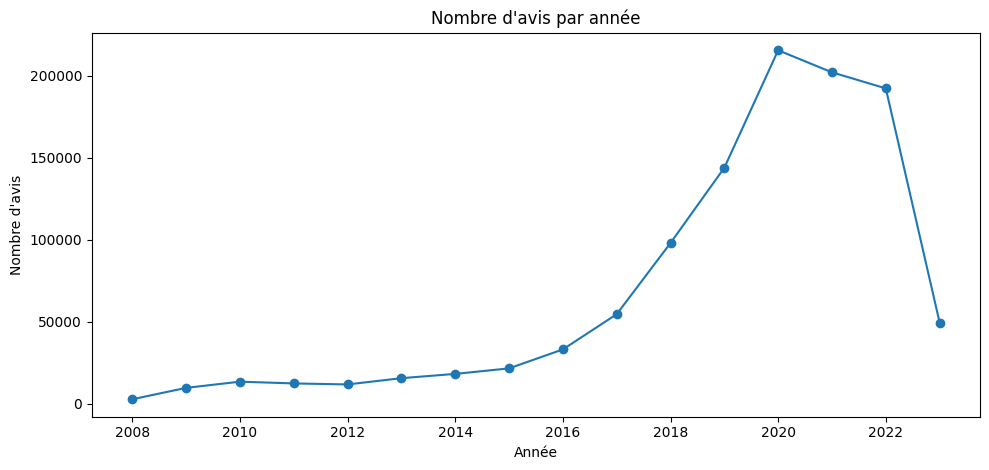

In [14]:
reviews["year"] = reviews["submission_time"].dt.year
reviews_by_year = reviews["year"].value_counts().sort_index()
display(reviews_by_year.to_frame("n_reviews").tail(20))

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(reviews_by_year.index, reviews_by_year.values, marker="o")
ax.set_title("Nombre d'avis par année")
ax.set_xlabel("Année")
ax.set_ylabel("Nombre d'avis")
fig.tight_layout()
fig.savefig(FIG_DIR / "09_reviews_by_year.png", dpi=160, bbox_inches="tight")
plt.show()

## 13. Avis par produit

,n_reviews
count,2351.000000
mean,465.508720
std,889.484946
min,1.000000
50%,164.000000
75%,488.500000
90%,1197.000000
95%,1963.500000
99%,4403.000000
max,16138.000000


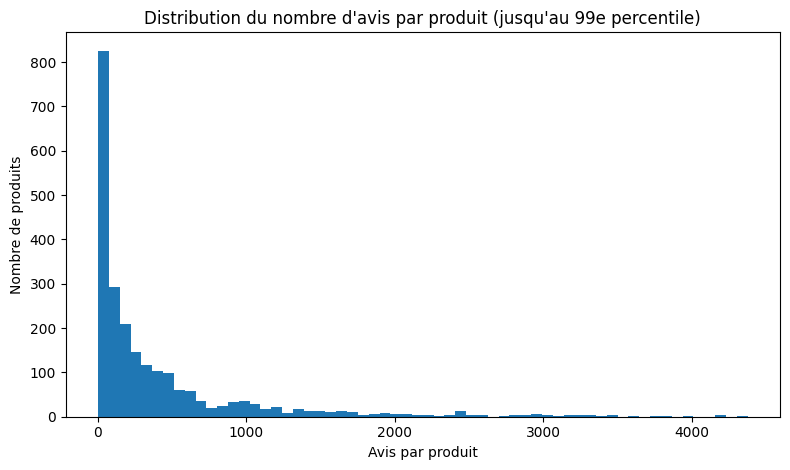

In [15]:
reviews_per_product = reviews.groupby("product_id").size().sort_values(ascending=False)
display(reviews_per_product.describe(percentiles=[.5,.75,.9,.95,.99]).to_frame("n_reviews"))

clip = reviews_per_product.quantile(.99)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(reviews_per_product[reviews_per_product <= clip], bins=60)
ax.set_title("Distribution du nombre d'avis par produit (jusqu'au 99e percentile)")
ax.set_xlabel("Avis par produit")
ax.set_ylabel("Nombre de produits")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_reviews_per_product.png", dpi=160, bbox_inches="tight")
plt.show()

,product_id,n_reviews,product_name,brand_name
387,P420652,16138,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE
2344,P7880,8736,Soy Hydrating Gentle Face Cleanser,fresh
42,P218700,7763,100 percent Pure Argan Oil,Josie Maran
54,P248407,7547,Ultra Repair Cream Intense Hydration,First Aid Beauty
60,P269122,7414,Alpha Beta Extra Strength Daily Peel Pads,Dr. Dennis Gross Skincare
199,P394639,7294,The True Cream Aqua Bomb,belif
359,P417238,6169,Green Clean Makeup Removing Cleansing Balm,Farmacy
931,P450271,6169,Green Clean Makeup Meltaway Cleansing Balm Lim...,Farmacy
484,P427421,6063,Protini Polypeptide Firming Refillable Moistur...,Drunk Elephant
307,P411387,5864,Superfood Antioxidant Cleanser,Youth To The People


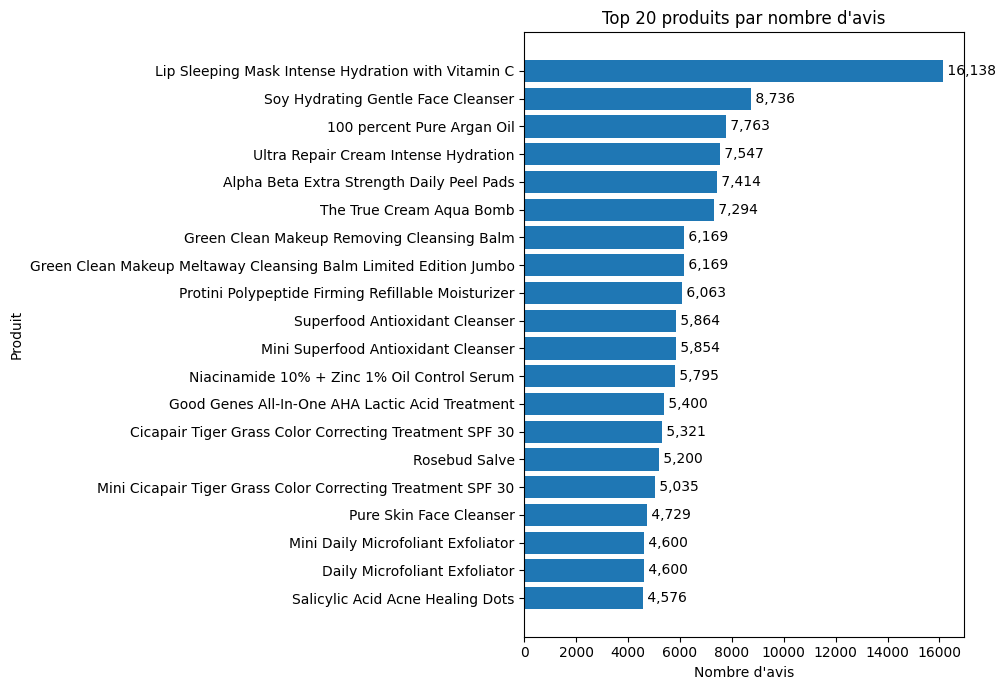

In [16]:
reviews_per_product_df = (
    reviews.groupby("product_id")
    .size()
    .reset_index(name="n_reviews")
)

top_products = (
    reviews_per_product_df
    .merge(
        products[["product_id", "product_name", "brand_name"]],
        on="product_id",
        how="left"
    )
    .sort_values("n_reviews", ascending=False)
    .head(20)
)

display(top_products)

top_products["label"] = (
    top_products["product_name"]
    .fillna(top_products["product_id"].astype(str))
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_products["label"][::-1],
    top_products["n_reviews"][::-1]
)

ax.set_title("Top 20 produits par nombre d'avis")
ax.set_xlabel("Nombre d'avis")
ax.set_ylabel("Produit")

for i, value in enumerate(top_products["n_reviews"][::-1]):
    ax.text(
        value,
        i,
        f" {value:,}",
        va="center"
    )

fig.tight_layout()

fig.savefig(
    FIG_DIR / "11_top_products_by_reviews.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

## 14. Marques les plus représentées

,n_reviews
brand_name,
CLINIQUE,49029
Tatcha,46770
Drunk Elephant,42395
fresh,40886
The Ordinary,35934
Glow Recipe,31490
Youth To The People,29154
Origins,29063
Peter Thomas Roth,28846


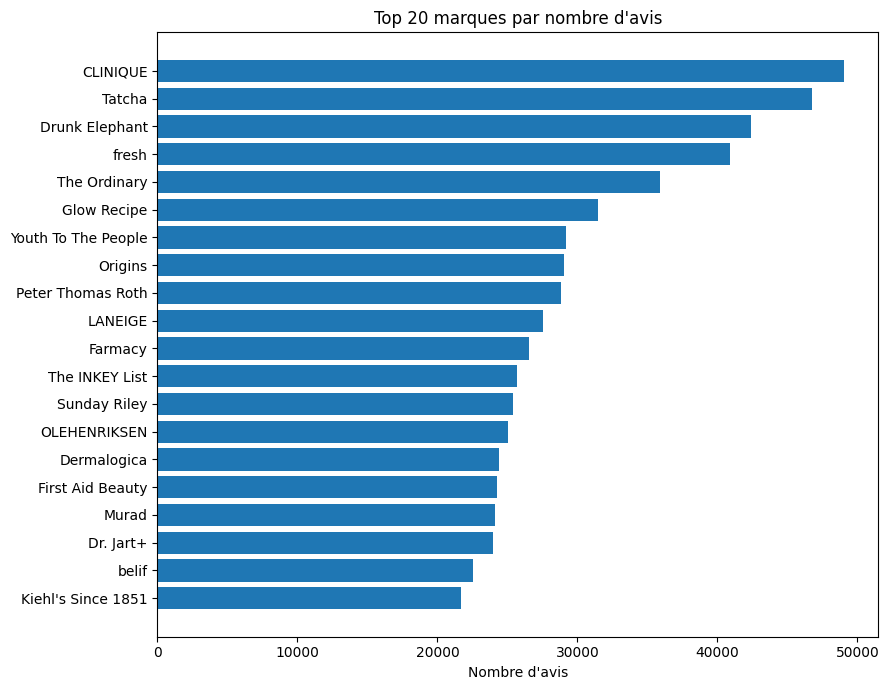

In [17]:
brand_counts = reviews["brand_name"].fillna("MISSING").value_counts().head(20).sort_values()
display(brand_counts.sort_values(ascending=False).to_frame("n_reviews"))

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(brand_counts.index, brand_counts.values)
ax.set_title("Top 20 marques par nombre d'avis")
ax.set_xlabel("Nombre d'avis")
fig.tight_layout()
fig.savefig(FIG_DIR / "11_top_brands_reviews.png", dpi=160, bbox_inches="tight")
plt.show()

In [18]:
brand_product_summary = (
    reviews.groupby("brand_name")
    .agg(
        n_reviews=("product_id", "size"),
        n_products=("product_id", "nunique")
    )
    .sort_values("n_reviews", ascending=False)
)

brand_product_summary["reviews_per_product"] = (
    brand_product_summary["n_reviews"]
    / brand_product_summary["n_products"]
)

display(brand_product_summary.head(20))

,n_reviews,n_products,reviews_per_product
brand_name,,,
CLINIQUE,49029,88,557.147727
Tatcha,46770,40,1169.250000
Drunk Elephant,42395,38,1115.657895
fresh,40886,48,851.791667
The Ordinary,35934,45,798.533333
Glow Recipe,31490,27,1166.296296
Youth To The People,29154,27,1079.777778
Origins,29063,38,764.815789
Peter Thomas Roth,28846,56,515.107143


## 15. Catégories skincare secondaires

,n_products
secondary_category,
Moisturizers,538
Treatments,452
Cleansers,354
Eye Care,184
Value & Gift Sets,170
Masks,165
Mini Size,110
Sunscreen,108
Wellness,79


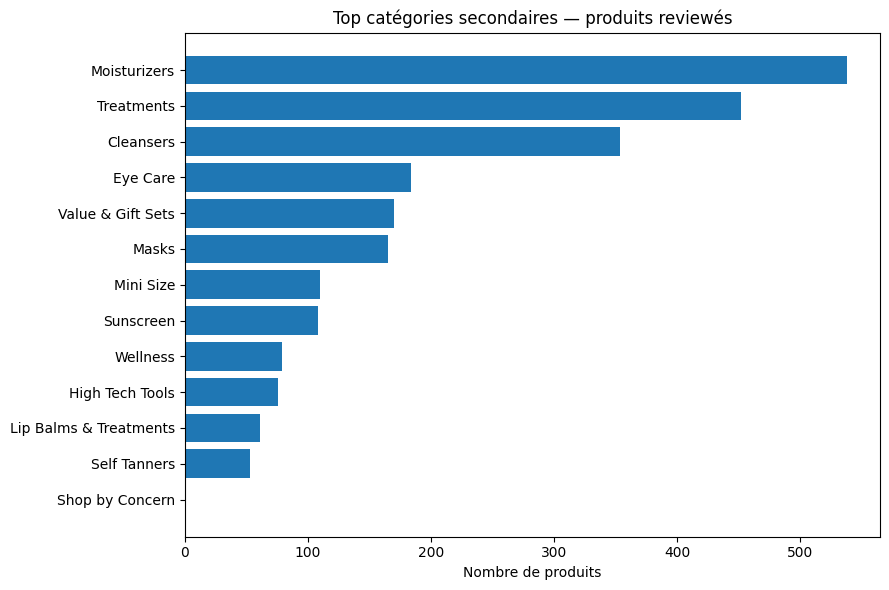

In [19]:
review_meta = reviews[["product_id"]].drop_duplicates().merge(
    products[["product_id", "primary_category", "secondary_category", "tertiary_category", "brand_name"]],
    on="product_id", how="left", suffixes=("", "_catalog")
)
secondary_counts = review_meta["secondary_category"].fillna("MISSING").value_counts().head(20).sort_values()
display(secondary_counts.sort_values(ascending=False).to_frame("n_products"))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(secondary_counts.index, secondary_counts.values)
ax.set_title("Top catégories secondaires — produits reviewés")
ax.set_xlabel("Nombre de produits")
fig.tight_layout()
fig.savefig(FIG_DIR / "12_secondary_categories.png", dpi=160, bbox_inches="tight")
plt.show()

## 16. Distribution des prix

,price_usd
count,2351.000000
mean,59.859103
std,69.421428
min,3.000000
50%,44.000000
75%,69.000000
90%,106.000000
95%,162.500000
99%,320.000000
max,1900.000000


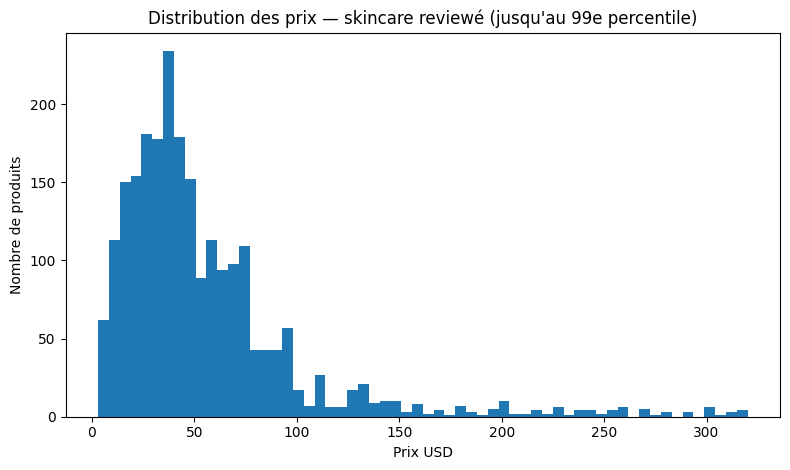

In [20]:
skincare_products = reviewed_products[reviewed_products["primary_category"].eq("Skincare")].copy()
price = skincare_products["price_usd"].dropna()
display(price.describe(percentiles=[.5,.75,.9,.95,.99]).to_frame("price_usd"))

upper = price.quantile(.99)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(price[price <= upper], bins=60)
ax.set_title("Distribution des prix — skincare reviewé (jusqu'au 99e percentile)")
ax.set_xlabel("Prix USD")
ax.set_ylabel("Nombre de produits")
fig.tight_layout()
fig.savefig(FIG_DIR / "13_skincare_price_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## 17. Disponibilité des ingrédients

In [21]:
ingredient_available = skincare_products["ingredients"].notna() & skincare_products["ingredients"].astype(str).str.strip().ne("")
print(f"Produits skincare reviewés avec ingrédients : {ingredient_available.sum():,}/{len(skincare_products):,} ({ingredient_available.mean():.2%})")

Produits skincare reviewés avec ingrédients : 2,224/2,351 (94.60%)


## 18. Doublons

In [22]:
from src.text_utils import normalize_for_dedup

# On garde uniquement les avis non vides
dedup_check = reviews.loc[
    ~empty_mask,
    ["author_id", "product_id", "review_text"]
].copy()

# Normalisation du texte
dedup_check["normalized_text"] = (
    dedup_check["review_text"]
    .map(normalize_for_dedup)
)

# 1. Doublons basés uniquement sur le texte
text_duplicates = dedup_check.duplicated(
    subset=["normalized_text"],
    keep="first"
)

# 2. Doublons plus stricts :
# même auteur + même produit + même texte
technical_duplicates = dedup_check.duplicated(
    subset=["author_id", "product_id", "normalized_text"],
    keep="first"
)

# Résumé
dup_comparison = pd.DataFrame({
    "type": [
        "Même texte normalisé",
        "Même auteur + même produit + même texte"
    ],
    "count": [
        int(text_duplicates.sum()),
        int(technical_duplicates.sum())
    ],
    "pct_reviews": [
        float(text_duplicates.mean() * 100),
        float(technical_duplicates.mean() * 100)
    ]
})

display(dup_comparison.round(2))

,type,count,pct_reviews
0,Même texte normalisé,123949,11.34
1,Même auteur + même produit + même texte,564,0.05


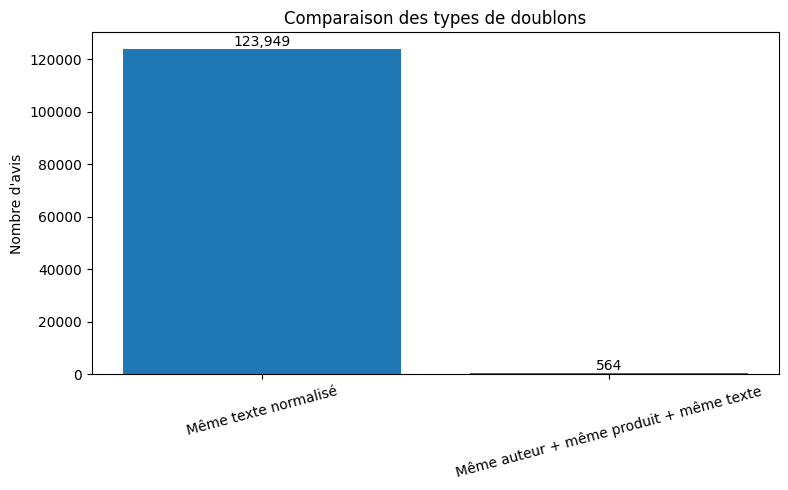

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    dup_comparison["type"],
    dup_comparison["count"]
)

ax.set_title("Comparaison des types de doublons")
ax.set_ylabel("Nombre d'avis")
ax.tick_params(axis="x", rotation=15)

for i, value in enumerate(dup_comparison["count"]):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

fig.tight_layout()

fig.savefig(
    FIG_DIR / "duplicate_comparison.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

## 19. Quasi-doublons

Diagnostic uniquement : ils ne sont pas supprimés automatiquement.

In [24]:
from src.text_utils import normalize_for_dedup

candidate_reviews = reviews.loc[
    (~empty_mask)
    & reviews["author_id"].notna()
    & reviews["product_id"].notna()
    & (reviews["review_word_count"] >= 12),
    [
        "author_id",
        "product_id",
        "review_text"
    ]
].copy()

# Normaliser
candidate_reviews["normalized_text"] = (
    candidate_reviews["review_text"]
    .map(normalize_for_dedup)
)

print("Avant retrait des doublons exacts :", len(candidate_reviews))

# -------------------------------------------------------
# RETIRER uniquement les doublons techniques EXACTS
# même auteur + même produit + même texte normalisé
# -------------------------------------------------------

candidate_reviews = candidate_reviews.drop_duplicates(
    subset=[
        "author_id",
        "product_id",
        "normalized_text"
    ],
    keep="first"
).copy()

print("Après retrait des doublons exacts :", len(candidate_reviews))

Avant retrait des doublons exacts : 1063757
Après retrait des doublons exacts : 1063211


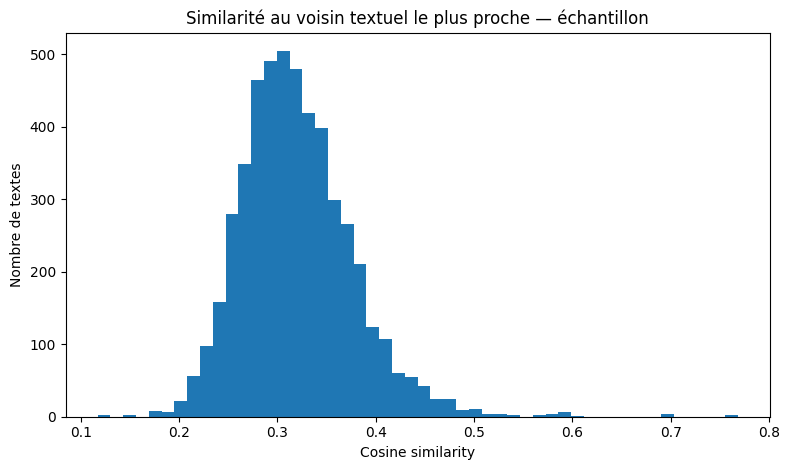

,nearest_similarity,review_text,nearest_text
2695,0.768239,Goes on smoothly and has a nice thin consisten...,Glides on smooth and does not have a strong sc...
2925,0.768239,Glides on smooth and does not have a strong sc...,Goes on smoothly and has a nice thin consisten...
4059,0.702415,The best exfoliator leaves my skin feeling so ...,The best exfoliator for my skin I love IT. My ...
4204,0.702415,The best exfoliator for my skin I love IT. My ...,The best exfoliator leaves my skin feeling so ...
1098,0.696931,Absolutely love this product and has become a ...,Love this product! It has definitely become a ...
3427,0.696931,Love this product! It has definitely become a ...,Absolutely love this product and has become a ...
3314,0.608939,"Love this Cleanser , it leaves my skin so fres...",The best exfoliator for my skin I love IT. My ...
2219,0.592705,I received this product from Influenster in ex...,I received this product complimentary from Inf...
435,0.592705,I received this product complimentary from Inf...,I received this product from Influenster in ex...
3665,0.588767,This razor is so cute and so effective! I love...,This Hanni weighted razor kit in the beautiful...


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

RUN_QUASI_DUPLICATE_DIAGNOSTIC = True
QUASI_SAMPLE = 5000

if RUN_QUASI_DUPLICATE_DIAGNOSTIC:
    pool = reviews.loc[(~empty_mask) & (reviews["review_word_count"] >= 12), ["review_text", "product_id"]].drop_duplicates("review_text")
    sample = pool.sample(min(QUASI_SAMPLE, len(pool)), random_state=SEED).reset_index(drop=True)
    vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=40_000)
    X = vec.fit_transform(sample["review_text"])
    nn = NearestNeighbors(n_neighbors=2, metric="cosine", algorithm="brute").fit(X)
    distances, indices = nn.kneighbors(X)
    similarity = 1 - distances[:, 1]
    sample["nearest_similarity"] = similarity
    sample["nearest_index"] = indices[:, 1]

    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.hist(similarity, bins=50)
    ax.set_title("Similarité au voisin textuel le plus proche — échantillon")
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Nombre de textes")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "14_quasi_duplicate_similarity_sample.png", dpi=160, bbox_inches="tight")
    plt.show()

    top_pairs = sample.sort_values("nearest_similarity", ascending=False).head(20).copy()
    top_pairs["nearest_text"] = [sample.loc[i, "review_text"] for i in top_pairs["nearest_index"]]
    display(top_pairs[["nearest_similarity", "review_text", "nearest_text"]])
    top_pairs.to_csv(TABLE_DIR / "quasi_duplicate_candidates_sample.csv", index=False)
else:
    print("Diagnostic quasi-doublons désactivé.")

## 20. Langues présentes

,count
review_text,
en,1993
fr,3
da,1
af,1
pt,1
es,1


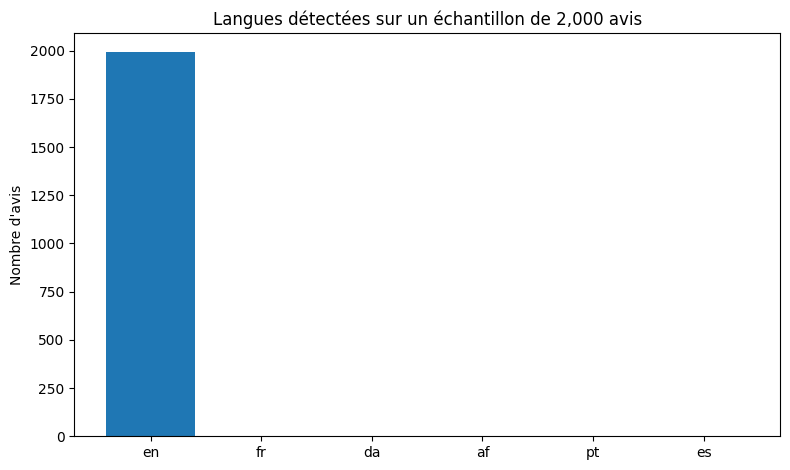

In [26]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = SEED

LANG_SAMPLE = 2000
lang_sample = reviews.loc[~empty_mask, "review_text"].sample(min(LANG_SAMPLE, (~empty_mask).sum()), random_state=SEED)

def safe_detect(x):
    try:
        return detect(str(x))
    except Exception:
        return "unknown"

langs = lang_sample.map(safe_detect).value_counts()
display(langs.to_frame("count"))

fig, ax = plt.subplots(figsize=(8, 4.8))
show_langs = langs.head(10)
ax.bar(show_langs.index, show_langs.values)
ax.set_title(f"Langues détectées sur un échantillon de {len(lang_sample):,} avis")
ax.set_ylabel("Nombre d'avis")
fig.tight_layout()
fig.savefig(FIG_DIR / "15_language_sample.png", dpi=160, bbox_inches="tight")
plt.show()

## 21. Unigrams

,term,count
2386,skin,118264
1996,product,60575
1521,love,38076
2829,use,35333
1471,like,33436
906,face,31800
2836,using,28083
2094,really,26406
780,dry,21445
2847,ve,19915


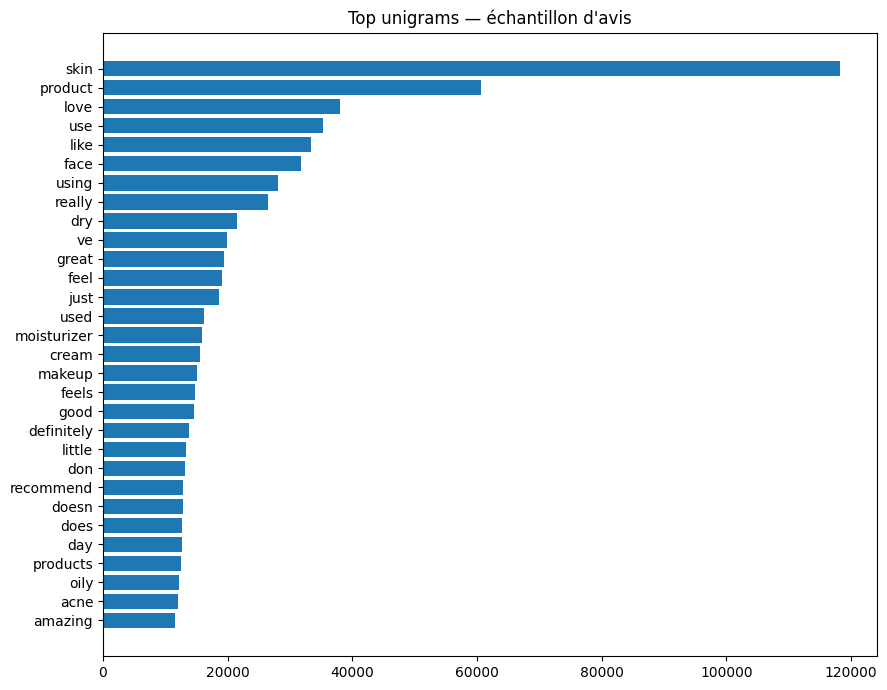

In [27]:
from sklearn.feature_extraction.text import CountVectorizer
TEXT_SAMPLE = 100_000
text_sample = reviews.loc[~empty_mask, "review_text"].sample(min(TEXT_SAMPLE, (~empty_mask).sum()), random_state=SEED)

cv1 = CountVectorizer(stop_words="english", min_df=10, max_features=3000, ngram_range=(1,1))
X1 = cv1.fit_transform(text_sample)
counts1 = np.asarray(X1.sum(axis=0)).ravel()
unigrams = pd.DataFrame({"term": cv1.get_feature_names_out(), "count": counts1}).sort_values("count", ascending=False).head(30)
display(unigrams)

fig, ax = plt.subplots(figsize=(9, 7))
plot_df = unigrams.sort_values("count")
ax.barh(plot_df["term"], plot_df["count"])
ax.set_title("Top unigrams — échantillon d'avis")
fig.tight_layout()
fig.savefig(FIG_DIR / "16_top_unigrams.png", dpi=160, bbox_inches="tight")
plt.show()

## 22. Bigrams

,term,count
792,dry skin,7760
2909,sensitive skin,7118
2723,received product,4685
1927,love product,4335
3046,skin feels,4298
2308,oily skin,4041
3832,ve using,3935
3044,skin feel,3881
1808,long way,3820
1990,makes skin,3762


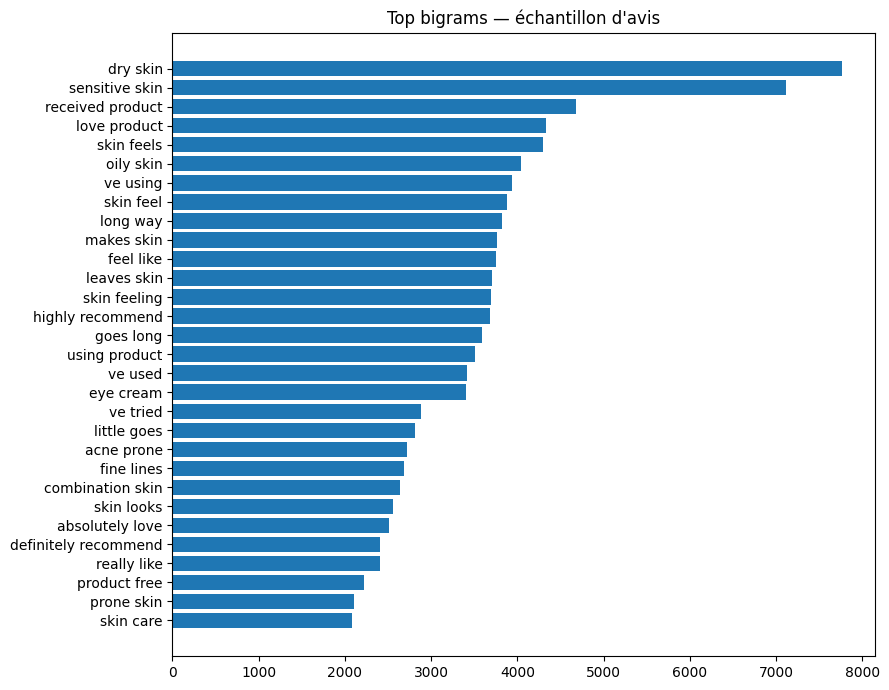

In [28]:
cv2 = CountVectorizer(stop_words="english", min_df=10, max_features=4000, ngram_range=(2,2))
X2 = cv2.fit_transform(text_sample)
counts2 = np.asarray(X2.sum(axis=0)).ravel()
bigrams = pd.DataFrame({"term": cv2.get_feature_names_out(), "count": counts2}).sort_values("count", ascending=False).head(30)
display(bigrams)

fig, ax = plt.subplots(figsize=(9, 7))
plot_df = bigrams.sort_values("count")
ax.barh(plot_df["term"], plot_df["count"])
ax.set_title("Top bigrams — échantillon d'avis")
fig.tight_layout()
fig.savefig(FIG_DIR / "17_top_bigrams.png", dpi=160, bbox_inches="tight")
plt.show()